# Import Packages

In [ ]:
%pip install optuna
%pip install optuna_integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 3.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
import optuna
from optuna.integration import XGBoostPruningCallback
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import VarianceThreshold, RFE, mutual_info_classif, mutual_info_regression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
education_and_occupation_df = pd.read_csv('/content/drive/My Drive/IS_II/datasets/education_and_occupation_data.csv')
education_and_occupation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92646 entries, 0 to 92645
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ENG.HS        92646 non-null  float64
 1   SC.HS         92646 non-null  float64
 2   MATH.HS       92646 non-null  float64
 3   CR.HS         92646 non-null  float64
 4   NS.HS         92646 non-null  float64
 5   degree        92646 non-null  object 
 6   degree.focus  92646 non-null  object 
 7   gender        92646 non-null  object 
 8   fefu          92646 non-null  object 
 9   femu          92646 non-null  object 
 10  fofu          92646 non-null  object 
 11  fomu          92646 non-null  object 
 12  int.s         92646 non-null  float64
 13  comp.s        92646 non-null  float64
 14  wasm.s        92646 non-null  float64
 15  car.s         92646 non-null  float64
 16  t.cred        92646 non-null  int64  
 17  t.parents     92646 non-null  int64  
 18  t.own         92646 non-nu

In [ ]:
numeric_columns = ['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'NS.HS','int.s', 'comp.s', 'wasm.s', 'car.s', 't.cred', 't.parents', 't.own']

# EDA

In [ ]:
education_and_occupation_df.describe()

,ENG.HS,SC.HS,MATH.HS,CR.HS,NS.HS,int.s,comp.s,wasm.s,car.s,t.cred,t.parents,t.own
count,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000
mean,56.013698,55.743697,56.532199,56.373539,56.028266,0.692509,0.803021,0.797484,0.392533,0.300992,0.720767,0.242831
std,14.110778,10.294171,11.357251,10.280244,10.892408,0.461455,0.397717,0.401875,0.488315,0.458690,0.448623,0.428794
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,49.000000,49.000000,50.000000,48.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,55.840000,55.890000,56.410000,55.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,62.000000,63.020000,63.000000,63.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,117.290000,108.280000,120.390000,113.190000,123.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
education_and_occupation_df.describe(include='object')

,degree,degree.focus,gender,fems,fefs
count,518542,518542,518542,518542,518542
unique,211,54,2,11,11
top,BUSINESS MANAGEMENT,MANAGEMENT,F,complete secondary school,complete secondary school
freq,47235,75902,313262,132045,144657


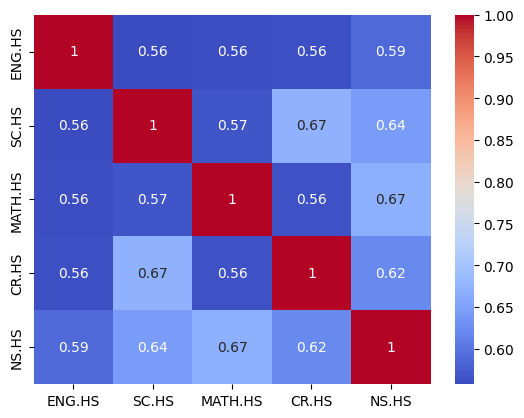

In [ ]:
corr = education_and_occupation_df[numeric_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
education_and_occupation_df.groupby('degree.focus')[numeric_columns].mean()

,ENG.HS,SC.HS,MATH.HS,CR.HS,NS.HS
degree.focus,,,,,
ADMINISTRATIVE AND RELATED ENGINEERING,61.620767,59.068728,61.536892,59.685814,59.676518
ADVERTISING AND RELATED,56.881436,55.139901,54.668868,56.499848,54.589639
"AGRICULTURAL, FORESTRY AND RELATED ENGINEERING",53.530443,57.116138,58.954072,57.060863,58.558139
"AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING",54.217804,55.916489,58.181009,56.347501,57.480768
"AGRONOMICAL, LIVESTOCK AND RELATED ENGINERING",51.098068,55.027636,55.562805,54.851996,55.771551
AGRONOMY,48.345556,51.942875,52.735097,51.660970,52.507972
ANTHROPOLOGY AND LIBERAL ARTS,65.682430,62.868198,60.760442,63.328512,61.622961
ARCHITECTURE,59.019148,56.722776,58.992539,57.608607,57.798786
BACTERIOLOGY,54.894162,56.942994,56.819961,57.888813,58.078154


# Preprocessing

### Encoding and Standardization

In [ ]:
df1_encoded = education_and_occupation_df.copy()
df1_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92646 entries, 0 to 92645
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ENG.HS        92646 non-null  float64
 1   SC.HS         92646 non-null  float64
 2   MATH.HS       92646 non-null  float64
 3   CR.HS         92646 non-null  float64
 4   NS.HS         92646 non-null  float64
 5   degree        92646 non-null  object 
 6   degree.focus  92646 non-null  object 
 7   gender        92646 non-null  object 
 8   fefu          92646 non-null  object 
 9   femu          92646 non-null  object 
 10  fofu          92646 non-null  object 
 11  fomu          92646 non-null  object 
 12  int.s         92646 non-null  float64
 13  comp.s        92646 non-null  float64
 14  wasm.s        92646 non-null  float64
 15  car.s         92646 non-null  float64
 16  t.cred        92646 non-null  int64  
 17  t.parents     92646 non-null  int64  
 18  t.own         92646 non-nu

In [ ]:
target = 'degree.category'

In [ ]:
# Define the categories for each column
categories_dict = {
    'fefu': [
        'incomplete primary school', 'complete Technical degree',
        'complete professional education', 'primary school complete',
        'incomplete secondary school', 'Incomplete professional education',
        'complete secondary school', 'Postgraduate',
        'incomplete technical degree', 'Does not know', 'does not apply'
    ],
    'femu': [
        'incomplete primary school', 'complete Technical degree',
        'complete professional education', 'primary school complete',
        'incomplete secondary school', 'Incomplete professional education',
        'complete secondary school', 'Postgraduate',
        'incomplete technical degree', 'Does not know', 'does not apply'
    ],
    'fofu': [
        'Independent professional', 'worker employee and operator',
        'Stay-at-home dad', 'Little Businessman', 'executive director',
        'Self-employed', 'Other activity or occupation',
        'Technical or professional level employee', 'Pensionado',
        'general manager', 'businessman', 'auxiliary level employee',
        'unemployed', 'does not apply', 'worker or government employee',
        'Worker or employee of a private company', 'employer',
        'Domestic employee', 'day laborer', 'Unpaid family worker',
        'Trabajador sin remuneración en empresas o negocios de otros hogares', 'Unknown'
    ],
    'fomu': [
        'Independent professional', 'worker employee and operator',
        'Stay-at-home dad', 'Little Businessman', 'executive director',
        'Self-employed', 'Other activity or occupation',
        'Technical or professional level employee', 'Pensionado',
        'general manager', 'businessman', 'auxiliary level employee',
        'unemployed', 'does not apply', 'worker or government employee',
        'Worker or employee of a private company', 'employer',
        'Domestic employee', 'day laborer', 'Unpaid family worker', 'Worker without remuneration',
        'Trabajador sin remuneración en empresas o negocios de otros hogares', 'Unknown'
    ],
    'gender': [
        'M', 'F',
    ]
}

# Apply OrdinalEncoder to each column
encoder = OrdinalEncoder(categories=list(categories_dict.values()))
columns_to_encode = list(categories_dict.keys())

# Fit and transform the columns
df1_encoded[columns_to_encode] = encoder.fit_transform(education_and_occupation_df[columns_to_encode])

# One-hot encode fofu and fomu columns
# df_encoded = pd.get_dummies(df_encoded, columns=['fofu', 'fomu'])


In [ ]:
# Set degree as Target
# Y = df1_encoded['degree.focus']
Y = df1_encoded['degree.category']
X = df1_encoded.drop(columns=['degree.focus', 'degree', 'degree.category'])

In [ ]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Encode target labels as integers
le = LabelEncoder()
Y = le.fit_transform(Y)

### Feature Selection

In [ ]:
mi_scores = mutual_info_classif(X, Y, random_state=42)

mi_df = pd.DataFrame({
    "Feature": df1_encoded.drop(columns=['degree', 'degree.focus']).columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

print("Mutual Information Scores:")
print(mi_df)

top_k = 10
selected_features = mi_df.head(top_k)["Feature"].tolist()
X_selected = X[:, [df1_encoded.drop(columns=['degree', 'degree.focus']).columns.get_loc(col) for col in selected_features]]

print("\nSelected features:", selected_features)

Mutual Information Scores:
      Feature  MI Score
2     MATH.HS  0.063213
5      gender  0.062451
4       NS.HS  0.055434
0      ENG.HS  0.052576
6        fefu  0.051178
7        femu  0.045761
8        fofu  0.041710
1       SC.HS  0.040427
9        fomu  0.037288
16      t.own  0.030740
3       CR.HS  0.030405
13      car.s  0.025802
15  t.parents  0.023786
10      int.s  0.016953
14     t.cred  0.011745
12     wasm.s  0.008858
11     comp.s  0.007597

Selected features: ['MATH.HS', 'gender', 'NS.HS', 'ENG.HS', 'fefu', 'femu', 'fofu', 'SC.HS', 'fomu', 't.own']


In [ ]:
# Select the top k features based on mutual information scores
X = X_selected

### Train Test Split and Resampling

In [ ]:
X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# Resampling to ensure class balance
# Check class distribution before resampling
print("Class distribution before resampling:", Counter(y_train))

# Apply RandomUnderSampler for undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Check class distribution after resampling
print("Class distribution after resampling:", Counter(y_train_resampled))

Class distribution before resampling: Counter({np.int64(25): 11535, np.int64(24): 6582, np.int64(17): 6526, np.int64(44): 5687, np.int64(23): 4428, np.int64(43): 2998, np.int64(28): 2878, np.int64(16): 2821, np.int64(50): 2661, np.int64(14): 2339, np.int64(46): 2102, np.int64(15): 1723, np.int64(32): 1577, np.int64(20): 1530, np.int64(19): 1488, np.int64(7): 1487, np.int64(27): 1435, np.int64(51): 1254, np.int64(47): 1214, np.int64(34): 1116, np.int64(53): 736, np.int64(10): 731, np.int64(1): 653, np.int64(3): 616, np.int64(12): 611, np.int64(29): 548, np.int64(42): 519, np.int64(0): 492, np.int64(18): 478, np.int64(13): 471, np.int64(8): 420, np.int64(41): 417, np.int64(54): 371, np.int64(4): 355, np.int64(2): 275, np.int64(48): 265, np.int64(21): 243, np.int64(31): 241, np.int64(45): 221, np.int64(36): 206, np.int64(49): 204, np.int64(30): 201, np.int64(33): 196, np.int64(11): 172, np.int64(26): 169, np.int64(39): 160, np.int64(6): 136, np.int64(5): 123, np.int64(35): 120, np.int64(5

# Training

## Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
rf_score = rf.score(X_train, y_train)
print("accuracy: " + str(rf_score))

accuracy: 0.22356846025149765


In [ ]:
rf_test_score = rf.score(X_test, y_test)
print("accuracy: " + str(rf_test_score))

accuracy: 0.16465191581219643


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
rf_tuned_top5_accuracy = top_k_accuracy_score(y_test, rf.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
rf_tuned_top10_accuracy = top_k_accuracy_score(y_test, rf.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"Random Forest Top 5 Accuracy: {rf_tuned_top5_accuracy}")
print(f"Random Forest Top 10 Accuracy: {rf_tuned_top10_accuracy}")

Random Forest Top 5 Accuracy: 0.5100917431192661
Random Forest Top 10 Accuracy: 0.7081489476524555


### Hyper Parameter Tuning

In [ ]:
# Objective function for RandomForestClassifier with Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": 42,
    }

    # Initialize and train the RandomForestClassifier
    rf_clf = RandomForestClassifier(**params)
    rf_clf.fit(X_train, y_train)

    # Predict and evaluate
    preds = rf_clf.predict(X_test)
    accuracy = accuracy_score(y_test, preds)

    return accuracy

# Run study
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, timeout=6000, show_progress_bar=False)

# Results
print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2025-09-24 19:55:20,832] A new study created in memory with name: no-name-6286c718-b67f-4364-b852-c67a4d86948a
[I 2025-09-24 19:55:23,169] Trial 0 finished with value: 0.35285158954150914 and parameters: {'n_estimators': 55, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 7, 'criterion': 'gini'}. Best is trial 0 with value: 0.35285158954150914.
[I 2025-09-24 19:55:24,566] Trial 1 finished with value: 0.3404867138825284 and parameters: {'n_estimators': 52, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.35285158954150914.
[I 2025-09-24 19:55:42,151] Trial 2 finished with value: 0.3681559188455189 and parameters: {'n_estimators': 152, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 10, 'criterion': 'entropy'}. Best is trial 2 with value: 0.3681559188455189.
[I 2025-09-24 19:55:48,092] Trial 3 finished with value: 0.36516321422865966 and parameters: {'n_estimators': 53, 'max_depth': 19, 'min_sa

Best params: {'n_estimators': 149, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 18, 'criterion': 'gini'}
Best accuracy: 0.371329676766601


In [ ]:
rf_tuned = RandomForestClassifier(n_estimators=149, random_state=42, max_depth=10, min_samples_split = 9, min_samples_leaf= 18, criterion='gini')
rf_tuned.fit(X_train, y_train)
rf_tuned_train_score = rf_tuned.score(X_train, y_train)
print("Train accuracy: " + str(rf_tuned_train_score))
rf_tuned_test_score = rf_tuned.score(X_test, y_test)
print("Train accuracy: " + str(rf_tuned_test_score))

Train accuracy: 0.44698932531868585
Train accuracy: 0.371329676766601


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
rf_tuned_top5_accuracy = top_k_accuracy_score(y_test, rf_tuned.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
rf_tuned_top10_accuracy = top_k_accuracy_score(y_test, rf_tuned.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"Random Forest Tuned Top 5 Accuracy: {rf_tuned_top5_accuracy}")
print(f"Random Forest Tuned Top 10 Accuracy: {rf_tuned_top10_accuracy}")

## XGB

In [ ]:
xgb_clf = XGBClassifier(n_estimators=100, max_depth=10, random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
xgb_score = xgb_clf.score(X_train, y_train)
print("XGB accuracy:", xgb_score)

XGB accuracy: 0.8737924334826488


In [ ]:
xgb_test_score = xgb_clf.score(X_test, y_test)
print("accuracy: " + str(xgb_test_score))

accuracy: 0.13135456017269292


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
xgb_clf_top5_accuracy = top_k_accuracy_score(y_test, xgb_clf.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
xgb_clf_top10_accuracy = top_k_accuracy_score(y_test, xgb_clf.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"XGB Top 5 Accuracy: {xgb_clf_top5_accuracy}")
print(f"XGB Top 10 Accuracy: {xgb_clf_top10_accuracy}")

XGB Top 5 Accuracy: 0.4614678899082569
XGB Top 10 Accuracy: 0.6702104695089045


### Hyper Parameter Tuning

In [ ]:
# Objective function with pruning and additional regularization

def objective(trial):
    params = {
        "objective": "multi:softmax",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "num_class": len(le.classes_),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "lambda": trial.suggest_float("lambda", 1, 5),  # L2 regularization
        "alpha": trial.suggest_float("alpha", 0, 5),    # L1 regularization
        "n_estimators": trial.suggest_int("n_estimators", 50, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
    }

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_test, label=y_test)

    # Optuna pruning callback
    pruning_callback = XGBoostPruningCallback(trial, "validation-mlogloss")

    # Train with validation set for pruning and early stopping
    bst = xgb.train(
        params,
        dtrain,
        evals=[(dtrain, "train"), (dvalid, "validation")],
        callbacks=[pruning_callback],
        early_stopping_rounds=20,
        verbose_eval=False,
    )

    # Predict and evaluate
    preds = bst.predict(dvalid)
    return accuracy_score(y_test, preds)

# Run study with pruning
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, timeout=6000, show_progress_bar=False)

# Results
print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2025-10-16 11:43:54,858] A new study created in memory with name: no-name-3ddb7f42-ebb6-4eb0-9f4d-e42538ace5aa
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [11:43:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
[I 2025-10-16 11:44:02,408] Trial 0 finished with value: 0.16400431732325957 and parameters: {'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.7672689405741958, 'colsample_bytree': 0.7639091281143204, 'gamma': 4.115740400168117, 'lambda': 3.40381703905542, 'alpha': 1.3530950730148716, 'n_estimators': 85, 'learning_rate': 0.10339466506333873}. Best is trial 0 with value: 0.16400431732325957.
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [11:44:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
[I 2025-10-16 11:44:06,599] Trial

Best params: {'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.8400882142580419, 'colsample_bytree': 0.7761197728510728, 'gamma': 0.28940876786533387, 'lambda': 3.646570456967111, 'alpha': 2.710360082413614, 'n_estimators': 61, 'learning_rate': 0.0681124997479961}
Best accuracy: 0.16551538046411224


In [ ]:
xgb_tuned = XGBClassifier(
    n_estimators=61,
    max_depth=8,
    random_state=42,
    eval_metric='mlogloss',
    min_child_weight = 8,
    subsample = 0.8400882142580419,
    colsample_bytree= 0.7761197728510728,
    gamma= 0.28940876786533387,
    reg_lambda = 3.646570456967111,
    alpha= 2.710360082413614,
    learning_rate = 0.0681124997479961
    )
xgb_tuned.fit(X_train, y_train)
xgb_score = xgb_clf.score(X_train, y_train)
print("XGB accuracy:", xgb_score)
xgb_test_score = xgb_clf.score(X_test, y_test)
print("accuracy: " , xgb_test_score)

XGB accuracy: 0.8737924334826488
accuracy:  0.13135456017269292


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
xgb_tuned_top5_accuracy = top_k_accuracy_score(y_test, xgb_tuned.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
xgb_tuned_top10_accuracy = top_k_accuracy_score(y_test, xgb_tuned.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"XGB Top 5 Accuracy: {xgb_tuned_top5_accuracy}")
print(f"XGB Top 10 Accuracy: {xgb_tuned_top10_accuracy}")

XGB Top 5 Accuracy: 0.5157042633567188
XGB Top 10 Accuracy: 0.7137075013491635


## KNN

In [ ]:
# Function to determin the optimal features to determine a target and the optimal K for that combination of features
def find_optimal_features_and_k(X, y, k_range=range(5, 21)):
    results = []

    best_score = 0
    best_k = None
    # Loop through k values
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        score = knn.score(X, y)

        # Update best parameters if better score is found
        if score > best_score:
            best_score = score
            best_k = k

        # Append results
        results.append({
            'k': k,
            'accuracy': score
        })

    print("optimal_k: " + str(best_k) + "\nbest_accuracy: " + str(best_score))

    return pd.DataFrame(results)


In [ ]:
results_df = find_optimal_features_and_k(X_train, y_train)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)
knn_score = knn.score(X_train_resampled, y_train_resampled)
print("KNN accuracy: " + str(knn_score))

In [ ]:
knn_test_score = knn.score(X_test, y_test)
print("accuracy: " + str(knn_test_score))

## GMLNET

In [ ]:
# GLMNET: Logistic Regression with Elastic Net regularization
glmnet = LogisticRegressionCV(
    Cs=10,
    # cv=5,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[.1, .5, .7, .9, 1],
    # multi_class='multinomial',
    # max_iter=1000,
    random_state=42
 )
glmnet.fit(X_train, y_train)
glmnet_train_score = glmnet.score(X_train, y_train)
print('GLMNET train accuracy:', glmnet_train_score)

GLMNET train accuracy: 0.1617599438717686


In [ ]:
glmnet_test_score = glmnet.score(X_test, y_test)
print('GLMNET test accuracy:', glmnet_test_score)

GLMNET test accuracy: 0.16006475984889368


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
glmnet_top5_accuracy = top_k_accuracy_score(y_test, glmnet.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
glmnet_top10_accuracy = top_k_accuracy_score(y_test, glmnet.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"GMNET Top 5 Accuracy: {glmnet_top5_accuracy}")
print(f"GMNET Top 10 Accuracy: {glmnet_top10_accuracy}")

GMNET Top 5 Accuracy: 0.5052887209929844
GMNET Top 10 Accuracy: 0.7034538586076633


## SVM

In [ ]:
svm_clf = SVC(kernel='linear', C=1, random_state=42)
svm_clf.fit(X_train, y_train)
svm_train_score = svm_clf.score(X_train, y_train)
print('SVM train accuracy:', svm_train_score)

SVM train accuracy: 0.3892242719452793


In [ ]:
svm_test_score = svm_clf.score(X_test, y_test)
print('SVM test accuracy:', svm_test_score)

SVM test accuracy: 0.3375898610149635


# Export Models